# Crowd Detection using HOG + SIFT + SVM

In [ ]:
!pip install scikit-image scikit-learn opencv-python opencv-contrib-python matplotlib Pillow scipy tqdm -q

print("✓ All packages installed successfully!")

✓ All packages installed successfully!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import os
import pickle
from tqdm import tqdm
import warnings
from glob import glob

warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully!")
print(f"OpenCV version: {cv2.__version__}")

✓ Libraries imported successfully!
OpenCV version: 4.12.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✓ Google Drive mounted successfully!")

Mounted at /content/drive
✓ Google Drive mounted successfully!


In [ ]:
# Base directory
BASE_DIR = '/content/drive/MyDrive/crowd_body_detection'

# Dataset paths (your existing samples)
POSITIVE_SAMPLES_DIR = f'{BASE_DIR}/data/positive_samples'
NEGATIVE_SAMPLES_DIR = f'{BASE_DIR}/data/negative_samples'
MODEL_DIR = f'{BASE_DIR}/models_sift'

# Image dimensions
BODY_WIDTH = 64
BODY_HEIGHT = 128
TARGET_SIZE = (BODY_WIDTH, BODY_HEIGHT)

# HOG parameters
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)

# SIFT parameters
SIFT_GRID_SIZE = (4, 8)
SIFT_DESCRIPTOR_SIZE = 128

# Detection parameters
WINDOW_SIZE = TARGET_SIZE
STEP_SIZE = 8
SCALE_FACTOR = 1.2
MIN_CONFIDENCE = 0.5
NMS_THRESHOLD = 0.3

# Create model directory
os.makedirs(MODEL_DIR, exist_ok=True)

print("✓ Configuration completed!")
print(f"  Target size: {TARGET_SIZE}")
print(f"  HOG config: {HOG_ORIENTATIONS} orientations, {HOG_PIXELS_PER_CELL} pixels/cell")
print(f"  SIFT config: Dense grid {SIFT_GRID_SIZE}")
print(f"  Positive samples dir: {POSITIVE_SAMPLES_DIR}")
print(f"  Negative samples dir: {NEGATIVE_SAMPLES_DIR}")

✓ Configuration completed!
  Target size: (64, 128)
  HOG config: 9 orientations, (8, 8) pixels/cell
  SIFT config: Dense grid (4, 8)
  Positive samples dir: /content/drive/MyDrive/crowd_body_detection/data/positive_samples
  Negative samples dir: /content/drive/MyDrive/crowd_body_detection/data/negative_samples


Feature Extraction Functions

In [ ]:
def extract_hog_features(image):
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize to target size
    image = cv2.resize(image, TARGET_SIZE)

    # Extract HOG features
    hog_features = hog(
        image,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm='L2-Hys',
        visualize=False,
        feature_vector=True
    )

    return hog_features


def extract_dense_sift_features(image, grid_size=SIFT_GRID_SIZE):
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize to target size
    image = cv2.resize(image, TARGET_SIZE)

    # Initialize SIFT
    sift = cv2.SIFT_create()

    # Calculate grid step
    h, w = image.shape
    step_x = w // grid_size[0]
    step_y = h // grid_size[1]

    # Create keypoints on a grid
    keypoints = []
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            x = step_x * i + step_x // 2
            y = step_y * j + step_y // 2
            keypoints.append(cv2.KeyPoint(x, y, step_x))

    # Compute SIFT descriptors at keypoints
    _, descriptors = sift.compute(image, keypoints)

    # Handle case where descriptors might be None
    if descriptors is None:
        descriptors = np.zeros((grid_size[0] * grid_size[1], SIFT_DESCRIPTOR_SIZE))

    # Flatten the descriptors
    sift_features = descriptors.flatten()

    return sift_features


def extract_fused_features(image):

    # Extract HOG features
    hog_features = extract_hog_features(image)

    # Extract SIFT features
    sift_features = extract_dense_sift_features(image)

    # Concatenate features
    fused_features = np.concatenate([hog_features, sift_features])

    return fused_features


print("✓ Feature extraction functions defined!")

# Test feature extraction
test_img = np.random.randint(0, 255, (128, 64, 3), dtype=np.uint8)
hog_feat = extract_hog_features(test_img)
sift_feat = extract_dense_sift_features(test_img)
fused_feat = extract_fused_features(test_img)

print(f"  HOG feature dimension: {len(hog_feat)}")
print(f"  SIFT feature dimension: {len(sift_feat)}")
print(f"  Fused feature dimension: {len(fused_feat)}")

✓ Feature extraction functions defined!
  HOG feature dimension: 3780
  SIFT feature dimension: 4096
  Fused feature dimension: 7876


In [ ]:
import random
def load_samples_from_directories(pos_dir, neg_dir, max_samples=None):

    print("Loading samples from directories...")

    positive_samples = []
    negative_samples = []

    # Get file lists
    pos_files = glob(os.path.join(pos_dir, '*.*'))
    neg_files = glob(os.path.join(neg_dir, '*.*'))

    # Shuffle file lists
    random.seed(42)
    random.shuffle(pos_files)
    random.shuffle(neg_files)

    if max_samples:
        pos_files = pos_files[:max_samples]
        neg_files = neg_files[:max_samples]

    # Load positive samples
    for img_path in tqdm(pos_files, desc="Loading positive samples"):
        img = cv2.imread(img_path)
        if img is not None:
            positive_samples.append(img)

    # Load negative samples
    for img_path in tqdm(neg_files, desc="Loading negative samples"):
        img = cv2.imread(img_path)
        if img is not None:
            negative_samples.append(img)

    print(f"✓ Loaded {len(positive_samples)} positive and {len(negative_samples)} negative samples")

    return np.array(positive_samples), np.array(negative_samples)


# Load your existing samples
positive_samples, negative_samples = load_samples_from_directories(
    POSITIVE_SAMPLES_DIR,
    NEGATIVE_SAMPLES_DIR,
    max_samples=5000
)

Loading samples from directories...


Loading negative samples: 100%|██████████| 5000/5000 [1:14:16<00:00,  1.12it/s]

✓ Loaded 5000 positive and 5000 negative samples


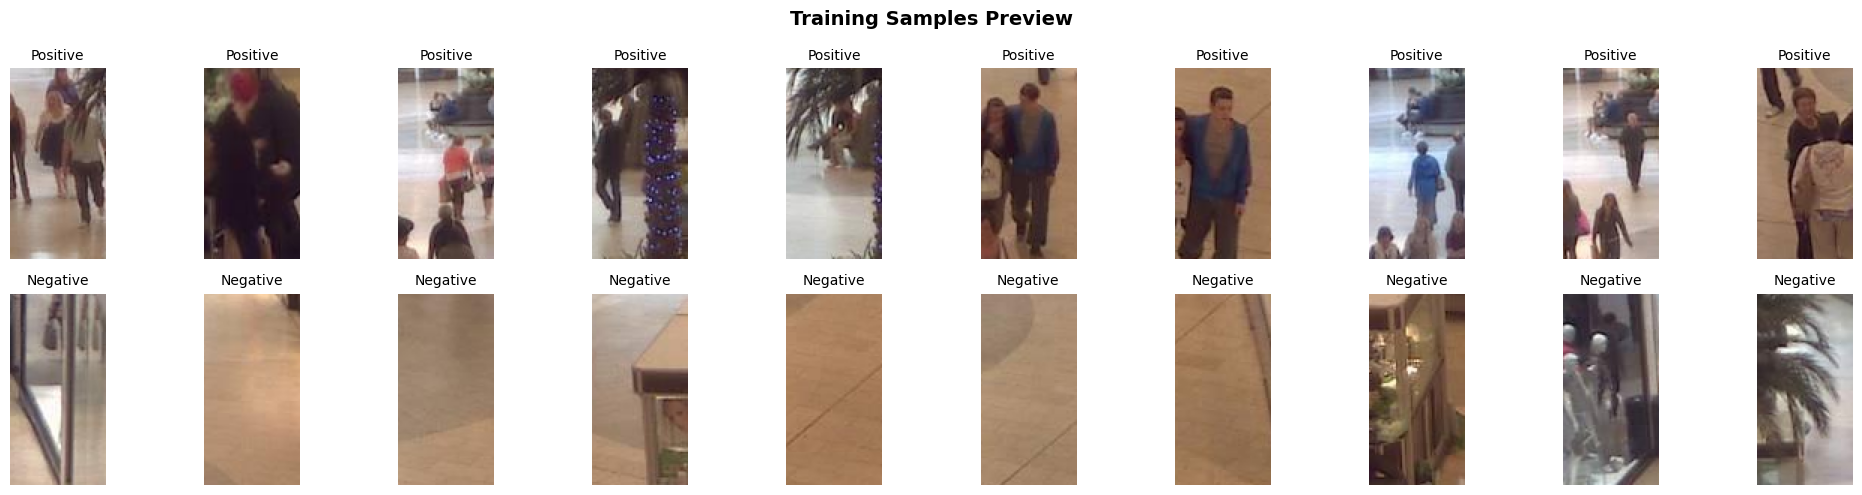

In [ ]:
def visualize_samples(positive_samples, negative_samples, num_samples=10):
    fig, axes = plt.subplots(2, num_samples, figsize=(20, 5))

    # Show positive samples
    for i in range(min(num_samples, len(positive_samples))):
        img = cv2.cvtColor(positive_samples[i], cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(img)
        axes[0, i].set_title('Positive', fontsize=10)
        axes[0, i].axis('off')

    # Show negative samples
    for i in range(min(num_samples, len(negative_samples))):
        img = cv2.cvtColor(negative_samples[i], cv2.COLOR_BGR2RGB)
        axes[1, i].imshow(img)
        axes[1, i].set_title('Negative', fontsize=10)
        axes[1, i].axis('off')

    plt.suptitle('Training Samples Preview', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


visualize_samples(positive_samples, negative_samples, num_samples=10)

Extract Features from Training Data

In [ ]:
def prepare_training_data(positive_samples, negative_samples):

    X = []
    y = []

    # Extract features from positive samples
    for img in tqdm(positive_samples, desc="Processing positive samples"):
        features = extract_fused_features(img)
        X.append(features)
        y.append(1)  # Positive label

    # Extract features from negative samples
    for img in tqdm(negative_samples, desc="Processing negative samples"):
        features = extract_fused_features(img)
        X.append(features)
        y.append(0)  # Negative label

    X = np.array(X)
    y = np.array(y)

    print(f"  Feature matrix shape: {X.shape}")
    print(f"  Labels shape: {y.shape}")
    print(f"  Positive samples: {np.sum(y == 1)}")
    print(f"  Negative samples: {np.sum(y == 0)}")

    return X, y


# Extract features
X, y = prepare_training_data(positive_samples, negative_samples)

Processing negative samples: 100%|██████████| 5000/5000 [01:03<00:00, 78.18it/s]


  Feature matrix shape: (10000, 7876)
  Labels shape: (10000,)
  Positive samples: 5000
  Negative samples: 5000


Train SVM Classifier

In [ ]:
def train_svm_classifier(X, y, test_size=0.2, random_state=42):

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    print(f"  Training samples: {len(X_train)}")
    print(f"  Test samples: {len(X_test)}")

    # Create pipeline with scaler and SVM
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', LinearSVC(C=1.0, max_iter=10000, dual=False, random_state=random_state))
    ])

    # Train
    print("\n  Training in progress...")
    pipeline.fit(X_train, y_train)

    # Evaluate
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n✓ Training completed!")
    print(f"\n{'='*60}")
    print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"{'='*60}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print("                 Predicted")
    print("                Neg    Pos")
    print(f"Actual  Neg   {cm[0,0]:5d}  {cm[0,1]:5d}")
    print(f"        Pos   {cm[1,0]:5d}  {cm[1,1]:5d}")

    return pipeline, X_test, y_test, y_pred


# Train the model
model_pipeline, X_test, y_test, y_pred = train_svm_classifier(X, y)

  Training samples: 8000
  Test samples: 2000

  Training in progress...

✓ Training completed!

Test Accuracy: 0.9795 (97.95%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.97      0.98      0.98      1000
    Positive       0.98      0.97      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000


Confusion Matrix:
                 Predicted
                Neg    Pos
Actual  Neg     985     15
        Pos      26    974


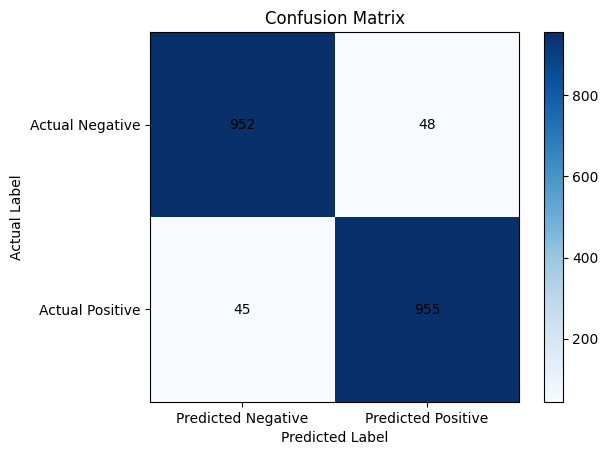

In [ ]:
# Save the trained model
model_path = os.path.join(MODEL_DIR, 'hog_sift_svm_model.pkl')

with open(model_path, 'wb') as f:
    pickle.dump(model_pipeline, f)

print(f"✓ Model saved to: {model_path}")

# Save configuration
config = {
    'target_size': TARGET_SIZE,
    'hog_orientations': HOG_ORIENTATIONS,
    'hog_pixels_per_cell': HOG_PIXELS_PER_CELL,
    'hog_cells_per_block': HOG_CELLS_PER_BLOCK,
    'sift_grid_size': SIFT_GRID_SIZE,
    'window_size': WINDOW_SIZE,
    'step_size': STEP_SIZE,
    'min_confidence': MIN_CONFIDENCE,
    'nms_threshold': NMS_THRESHOLD
}

config_path = os.path.join(MODEL_DIR, 'model_config.pkl')
with open(config_path, 'wb') as f:
    pickle.dump(config, f)

print(f"✓ Configuration saved to: {config_path}")

✓ Model saved to: /content/drive/MyDrive/crowd_body_detection/models_sift/hog_sift_svm_model.pkl
✓ Configuration saved to: /content/drive/MyDrive/crowd_body_detection/models_sift/model_config.pkl


In [ ]:
def sliding_window(image, window_size, step_size):
    h, w = image.shape[:2]
    win_w, win_h = window_size

    for y in range(0, h - win_h + 1, step_size):
        for x in range(0, w - win_w + 1, step_size):
            yield (x, y, image[y:y+win_h, x:x+win_w])


def pyramid(image, scale=1.2, min_size=(64, 128)):
    yield image, 1.0

    # Scale down
    current_scale = 1.0
    while True:
        current_scale /= scale
        h, w = image.shape[:2]
        new_h, new_w = int(h * current_scale), int(w * current_scale)

        if new_w < min_size[0] or new_h < min_size[1]:
            break

        scaled = cv2.resize(image, (new_w, new_h))
        yield scaled, current_scale


def non_max_suppression(boxes, scores, threshold=0.3):
    if len(boxes) == 0:
        return []

    boxes = np.array(boxes)
    scores = np.array(scores)

    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 0] + boxes[:, 2]
    y2 = boxes[:, 1] + boxes[:, 3]

    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]

    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)
        inter = w * h

        union = areas[i] + areas[order[1:]] - inter
        iou = inter / union

        inds = np.where(iou <= threshold)[0]
        order = order[inds + 1]

    return keep


print("✓ Detection functions defined!")

✓ Detection functions defined!


In [ ]:
def detect_people(image, model, window_size=WINDOW_SIZE, step_size=STEP_SIZE,
                 scale_factor=SCALE_FACTOR, min_confidence=MIN_CONFIDENCE,
                 nms_threshold=NMS_THRESHOLD, show_progress=True):
    detections = []
    total_windows = 0

    if show_progress:
        print("Running detection...")

    # Create image pyramid
    for scale_idx, (scaled_img, scale) in enumerate(pyramid(image, scale=scale_factor, min_size=window_size)):
        if show_progress:
            print(f"  Scale {scale_idx+1}: {scaled_img.shape[1]}x{scaled_img.shape[0]} (factor: {scale:.3f})", end='')

        windows_at_scale = 0

        # Slide window across image
        for (x, y, window) in sliding_window(scaled_img, window_size, step_size):
            # Check if window is the correct size
            if window.shape[0] != window_size[1] or window.shape[1] != window_size[0]:
                continue

            windows_at_scale += 1
            total_windows += 1

            # Extract features
            features = extract_fused_features(window)
            features = features.reshape(1, -1)

            # Predict
            prediction = model.predict(features)[0]

            if prediction == 1:
                # Get decision function score
                score = model.decision_function(features)[0]

                if score >= min_confidence:
                    # Scale coordinates back to original image
                    orig_x = int(x / scale)
                    orig_y = int(y / scale)
                    orig_w = int(window_size[0] / scale)
                    orig_h = int(window_size[1] / scale)

                    detections.append([orig_x, orig_y, orig_w, orig_h, score])

        if show_progress:
            print(f" - {windows_at_scale} windows checked")

    if show_progress:
        print(f"\n  Total windows checked: {total_windows}")
        print(f"  Raw detections before NMS: {len(detections)}")

    # Apply Non-Maximum Suppression
    if len(detections) > 0:
        detections = np.array(detections)
        boxes = detections[:, :4]
        scores = detections[:, 4]

        keep = non_max_suppression(boxes, scores, threshold=nms_threshold)
        detections = detections[keep]

        if show_progress:
            print(f"  Final detections after NMS: {len(detections)}")

    return detections


def visualize_detections(image, detections, title="Detections"):
    # Convert BGR to RGB for display
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, figsize=(15, 10))
    ax.imshow(img_rgb)

    # Draw bounding boxes
    for detection in detections:
        x, y, w, h, score = detection
        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2,
            edgecolor='lime',
            facecolor='none'
        )
        ax.add_patch(rect)

        # Add confidence score
        ax.text(x, y - 5, f'{score:.2f}',
               bbox=dict(boxstyle='round', facecolor='lime', alpha=0.8),
               fontsize=10, color='black', fontweight='bold')

    ax.set_title(f"{title} - {len(detections)} people detected", fontsize=16, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


print("✓ Main detection function defined!")

✓ Main detection function defined!


Image loaded: 640x480 pixels

Running detection...
  Scale 1: 640x480 (factor: 1.000) - 3285 windows checked
  Scale 2: 533x400 (factor: 0.833) - 2065 windows checked
  Scale 3: 444x333 (factor: 0.694) - 1248 windows checked
  Scale 4: 370x277 (factor: 0.579) - 741 windows checked
  Scale 5: 308x231 (factor: 0.482) - 403 windows checked
  Scale 6: 257x192 (factor: 0.402) - 225 windows checked
  Scale 7: 214x160 (factor: 0.335) - 95 windows checked
  Scale 8: 178x133 (factor: 0.279) - 15 windows checked

  Total windows checked: 8077
  Raw detections before NMS: 44
  Final detections after NMS: 11


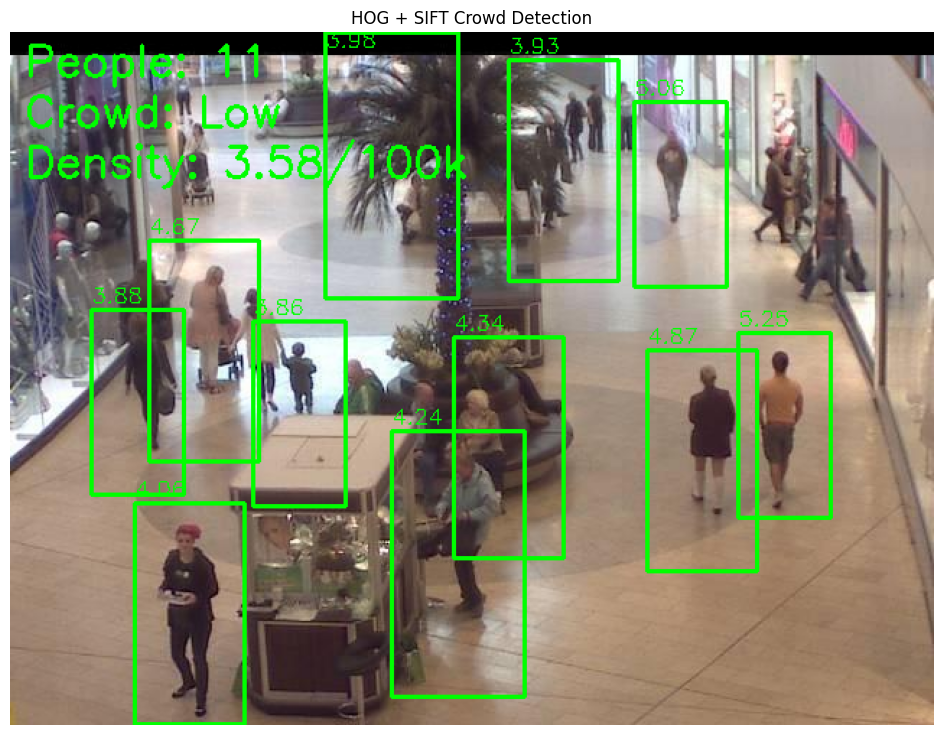

In [ ]:
import cv2
import matplotlib.pyplot as plt

test_image_path = '/content/drive/MyDrive/crowd_body_detection/data/test_images/seq_001959.jpg'

if os.path.exists(test_image_path):
    test_img = cv2.imread(test_image_path)

    if test_img is None:
        raise ValueError("Image failed to load")

    print(f"Image loaded: {test_img.shape[1]}x{test_img.shape[0]} pixels\n")

    # Run detection
    detections = detect_people(
        test_img,
        model_pipeline,
        step_size=STEP_SIZE,
        min_confidence=3.8,
        nms_threshold=0.25
    )

    # Copy image for drawing
    result = test_img.copy()

    # Draw bounding boxes
    for det in detections:
        x, y, w, h, score = det
        x, y, w, h = int(x), int(y), int(w), int(h)

        cv2.rectangle(
            result,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

        cv2.putText(
            result,
            f"{score:.2f}",
            (x, max(y - 5, 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1
        )

    # Crowd info
    num_people = len(detections)
    h_img, w_img = result.shape[:2]
    density = (num_people / (w_img * h_img)) * 100000

    if density < 5:
        crowd_level = "Low"
    elif density < 15:
        crowd_level = "Medium"
    elif density < 30:
        crowd_level = "High"
    else:
        crowd_level = "Very High"

    cv2.putText(result, f"People: {num_people}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(result, f"Crowd: {crowd_level}", (10, 65),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(result, f"Density: {density:.2f}", (10, 100),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    plt.figure(figsize=(14, 9))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title("HOG + SIFT Crowd Detection")
    plt.axis("off")
    plt.show()

else:
    print(f"Image not found at: {test_image_path}")


## visualization on hog & sift

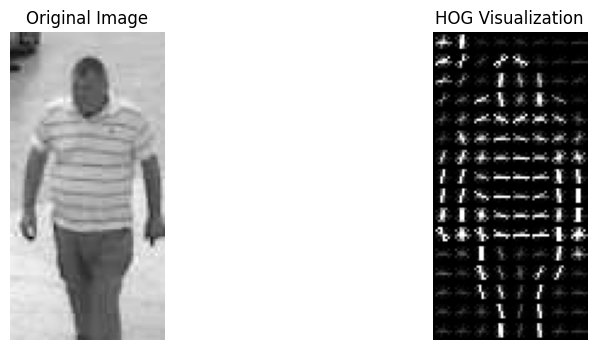

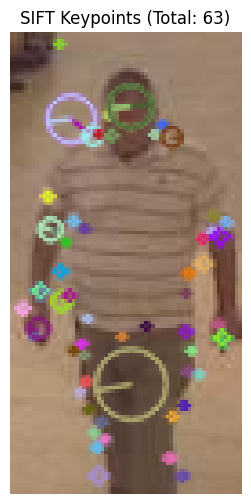

In [ ]:
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure

img_path = '/content/drive/MyDrive/crowd_body_detection/data/test_images/pos_seq_000497.jpg_19.png'
img = cv2.imread(img_path)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

img_gray = cv2.resize(img_gray, (64, 128))

hog_features, hog_image = hog(
    img_gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True,
    block_norm='L2-Hys'
)

hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("HOG Visualization")
plt.imshow(hog_image_rescaled, cmap='gray')
plt.axis('off')

plt.show()


img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray, None)

sift_img = cv2.drawKeypoints(
    img,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(6,6))
plt.title(f"SIFT Keypoints (Total: {len(keypoints)})")
plt.imshow(cv2.cvtColor(sift_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
